<a href="https://colab.research.google.com/github/adiban17/Deep-Learning-Models/blob/main/LSTM_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Long Short-Term Memory (LSTM)**

In this notebook I have implemented the following LSTM architectures:
1. Stacked (Deep) LSTM
2. Bidirectional LSTM (BiLSTM)
3. Multilayer LSTM
4. Stateful LSTM
5. Residual LSTM  

Dataset Used : Marsh Stock (MRSH - Closing Price)

Task : Time-Series Prediction (Regression)

Installs and Imports

In [22]:
!pip install yfinance

Import Necessary Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Input, Add

Load Dataset

In [24]:
df = yf.download('MRSH', period='5y');
data = df[['Close']];
print(data.head(10));

/tmp/ipykernel_6248/385982700.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('MRSH', period='5y');
[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            MRSH
Date                  
2021-06-03  129.165894
2021-06-04  129.443893
2021-06-07  127.868393
2021-06-08  127.349358
2021-06-09  127.358658
2021-06-10  128.350311
2021-06-11  128.748840
2021-06-14  129.406860
2021-06-15  130.333664
2021-06-16  129.481003


PreProcessing

In [25]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

window_size = 30

X, y = [], []

for i in range(window_size, len(scaled_data)):
  X.append(scaled_data[i-window_size: i])
  y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

Splitting into Train and Test Sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [27]:
X.shape, y.shape

((1225, 30, 1), (1225, 1))

In [28]:
X_train.shape, X_test.shape

((980, 30, 1), (245, 30, 1))

In [29]:
y_train.shape, y_test.shape

((980, 1), (245, 1))

In [30]:
X[0]

array([[0.04070715],
       [0.04312031],
       [0.02944432],
       [0.02493888],
       [0.02501961],
       [0.03362757],
       [0.03708696],
       [0.04279884],
       [0.05084387],
       [0.04344243],
       [0.02035358],
       [0.        ],
       [0.01633099],
       [0.01938826],
       [0.0255828 ],
       [0.03089242],
       [0.0433615 ],
       [0.03732829],
       [0.05333756],
       [0.0512456 ],
       [0.06460026],
       [0.0643588 ],
       [0.06628969],
       [0.06645049],
       [0.05800359],
       [0.06669195],
       [0.06049741],
       [0.05422261],
       [0.05349836],
       [0.05422261]])

In [31]:
X[30]

array([[0.05647483],
       [0.03805201],
       [0.05945143],
       [0.06500252],
       [0.09323966],
       [0.10538768],
       [0.10723804],
       [0.09975646],
       [0.08857376],
       [0.10480263],
       [0.10819408],
       [0.11441114],
       [0.13330522],
       [0.12167801],
       [0.13814967],
       [0.12975231],
       [0.13580817],
       [0.13322416],
       [0.14347836],
       [0.13936134],
       [0.14388234],
       [0.15914273],
       [0.16713637],
       [0.15437907],
       [0.16229192],
       [0.17206161],
       [0.17795588],
       [0.17319223],
       [0.17359581],
       [0.16875123]])

In [32]:
y[0]

array([0.05647483])

In [33]:
X[31]

array([[0.03805201],
       [0.05945143],
       [0.06500252],
       [0.09323966],
       [0.10538768],
       [0.10723804],
       [0.09975646],
       [0.08857376],
       [0.10480263],
       [0.10819408],
       [0.11441114],
       [0.13330522],
       [0.12167801],
       [0.13814967],
       [0.12975231],
       [0.13580817],
       [0.13322416],
       [0.14347836],
       [0.13936134],
       [0.14388234],
       [0.15914273],
       [0.16713637],
       [0.15437907],
       [0.16229192],
       [0.17206161],
       [0.17795588],
       [0.17319223],
       [0.17359581],
       [0.16875123],
       [0.18191224]])

In [34]:
y[1]

array([0.03805201])

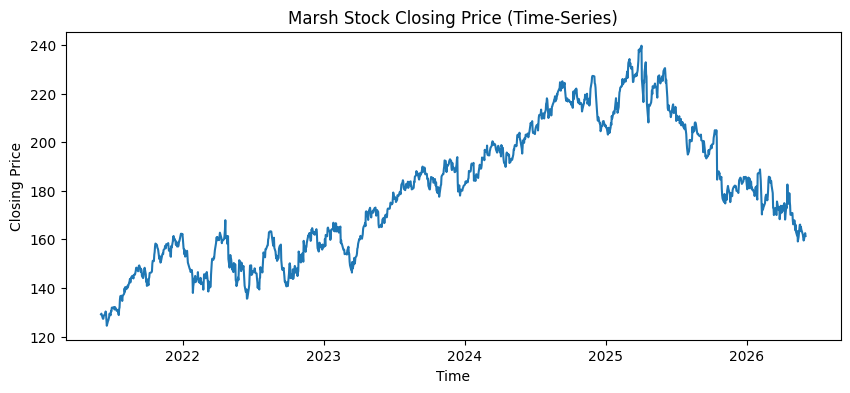

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(df['Close'])
plt.title('Marsh Stock Closing Price (Time-Series)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()

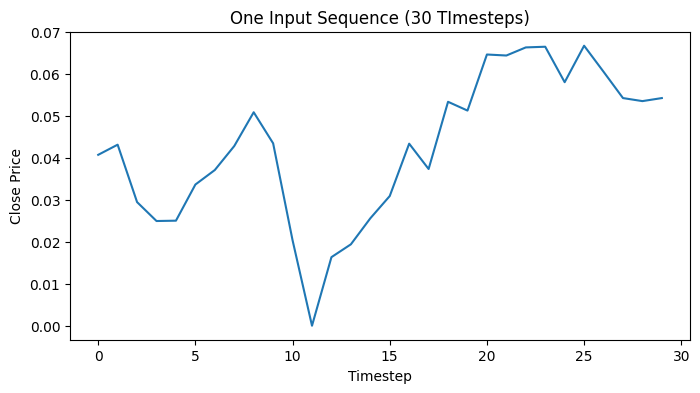

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(X[0])
plt.title("One Input Sequence (30 TImesteps)")
plt.xlabel("Timestep")
plt.ylabel("Close Price")
plt.show()

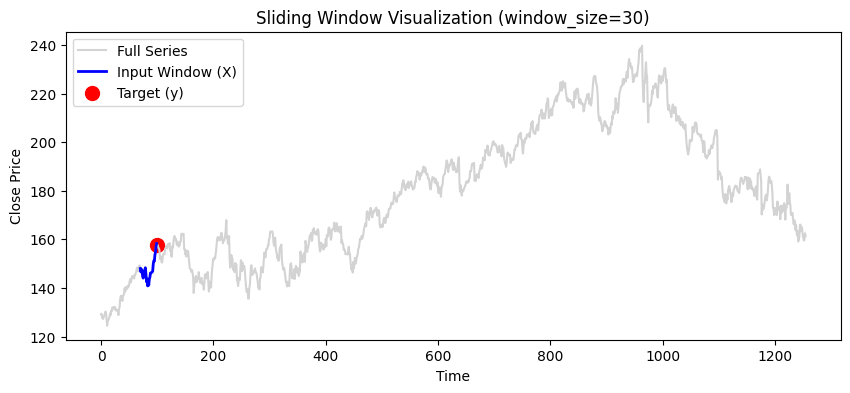

In [37]:
# Choose a sample index
i = 100

window_size = 30

plt.figure(figsize=(10, 4))

# Full Series (light background)
plt.plot(df['Close'].values, color='lightgray', label='Full Series')

# Sliding Window (X)
plt.plot(range(i-window_size, i), df['Close'].values[i-window_size: i], color='blue', linewidth=2, label='Input Window (X)')

# Target Value (y)
plt.scatter(i, df['Close'].values[i], color='red', s=100, label='Target (y)')
plt.title('Sliding Window Visualization (window_size=30)')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

Utility Function

In [42]:
def complile_and_train(model, name, epochs=10, batch_size=32):
  model.compile(optimizer='adam', loss='mse')
  history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
  print(f"{name} trained")
  return history

### **Deep/Stacked LSTM**

In [63]:
# Hyperparameters
window_size = 30
batch_size = 32
epochs = 10

stacked_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])

stacked_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_stacked = complile_and_train(stacked_lstm, "Stacked LSTM")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0374
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0025
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0015
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0015
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0015
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0015
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013
Stacked LSTM trained


Prediction

In [65]:
# Model Prediction
prediction = stacked_lstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual:{actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Predicted: 224.48
Actual:213.21
Predicted: 223.09
Actual:215.28
Predicted: 221.76
Actual:213.29
Predicted: 220.38
Actual:212.56
Predicted: 219.04
Actual:211.97
Predicted: 217.75
Actual:210.29
Predicted: 216.48
Actual:212.15
Predicted: 215.42
Actual:214.99
Predicted: 214.73
Actual:215.54
Predicted: 214.31
Actual:212.24
Predicted: 213.88
Actual:211.96
Predicted: 213.46
Actual:212.89
Predicted: 213.14
Actual:214.53
Predicted: 213.00
Actual:213.74
Predicted: 212.92
Actual:208.72
Predicted: 212.56
Actual:211.04
Predicted: 212.23
Actual:209.15
Predicted: 211.80
Actual:209.16
Predicted: 211.36
Actual:210.14
Predicted: 210.99
Actual:210.67
Predicted: 210.71
Actual:207.76
Predicted: 210.32
Actual:209.56
Predicted: 210.02
Actual:206.94
Predicted: 209.62
Actual:208.00
Predicted: 209.25
Actual:207.07
Predicted: 208.87
Actual:208.29
Predicted: 208.58
Actual:206.06
Predicted: 208.22
Actual:206.35
Predicted: 207.86
Actual:205.86
Predicted: 207.50
Actual:205.28
Pr

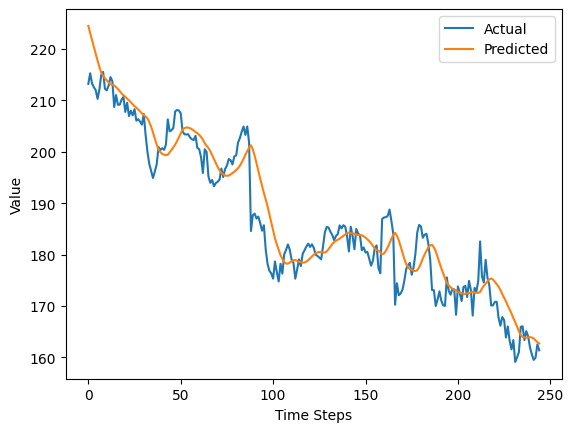

In [66]:
# Plotting (Actual vs Predicted Values)
plt.figure()
plt.plot(actual, label='Actual')
plt.plot(prediction, label='Predicted')
plt.xlabel("Time Steps")
plt.ylabel('Value')
plt.legend()
plt.show()

### **Bidirectional LSTM**

In [67]:
bilstm = Sequential([
    Input(shape=(window_size, 1)),
    Bidirectional(LSTM(50)),
    Dense(1)
])
bilstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history_bilstm = complile_and_train(bilstm, "Bidirectional LSTM")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0413
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0049
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0028
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0025
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0023
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0022
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0021
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0020
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0018
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0017
Bidirectional LSTM trained


#### Prediction

In [69]:
# Model Prediction
prediction = bilstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual:{actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Predicted: 222.63
Actual:213.21
Predicted: 221.64
Actual:215.28
Predicted: 220.57
Actual:213.29
Predicted: 219.52
Actual:212.56
Predicted: 218.39
Actual:211.97
Predicted: 217.36
Actual:210.29
Predicted: 216.34
Actual:212.15
Predicted: 215.48
Actual:214.99
Predicted: 214.94
Actual:215.54
Predicted: 214.75
Actual:212.24
Predicted: 214.63
Actual:211.96
Predicted: 214.67
Actual:212.89
Predicted: 214.80
Actual:214.53
Predicted: 214.88
Actual:213.74
Predicted: 214.88
Actual:208.72
Predicted: 214.65
Actual:211.04
Predicted: 214.48
Actual:209.15
Predicted: 214.30
Actual:209.16
Predicted: 214.08
Actual:210.14
Predicted: 213.85
Actual:210.67
Predicted: 213.60
Actual:207.76
Predicted: 213.26
Actual:209.56
Predicted: 212.81
Actual:206.94
Predicted: 212.11
Actual:208.00
Predicted: 211.31
Actual:207.07
Predicted: 210.44
Actual:208.29
Predicted: 209.69
Actual:206.06
Predicted: 208.95
Actual:206.35
Predicted: 208.21
Actual:205.86
Predicted: 207.75
Actual:205.28
Pr

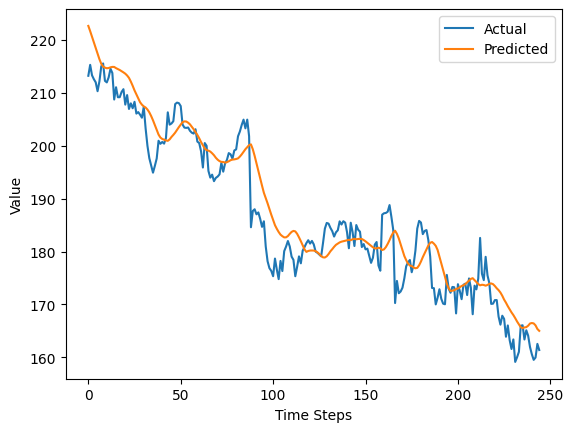

In [70]:
# Plotting (Actual vs Predicted Values)
plt.figure()
plt.plot(actual, label='Actual')
plt.plot(prediction, label='Predicted')
plt.xlabel("Time Steps")
plt.ylabel('Value')
plt.legend()
plt.show()

### **Multi-Layer LSTM**

Multiple LSTM Layers with Decreasing Units

In [71]:
multilayer_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(100, return_sequences=True),
    LSTM(50, return_sequences=True),
    LSTM(25),
    Dense(1)
])
multilayer_lstm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,626 (307.13 KB)

 Trainable params: 78,626 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history_multilayer = complile_and_train(multilayer_lstm, "Multilayer LSTM")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0370
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0027
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0022
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0021
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0021
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0020
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0019
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0020
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0020
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0019
Multilayer LSTM trained


#### Prediction

In [73]:
# Model Prediction
prediction = multilayer_lstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual:{actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Predicted: 223.96
Actual:213.21
Predicted: 223.44
Actual:215.28
Predicted: 222.70
Actual:213.29
Predicted: 221.75
Actual:212.56
Predicted: 220.66
Actual:211.97
Predicted: 219.47
Actual:210.29
Predicted: 218.21
Actual:212.15
Predicted: 216.97
Actual:214.99
Predicted: 215.82
Actual:215.54
Predicted: 214.82
Actual:212.24
Predicted: 213.96
Actual:211.96
Predicted: 213.23
Actual:212.89
Predicted: 212.62
Actual:214.53
Predicted: 212.16
Actual:213.74
Predicted: 211.84
Actual:208.72
Predicted: 211.55
Actual:211.04
Predicted: 211.29
Actual:209.15
Predicted: 211.01
Actual:209.16
Predicted: 210.73
Actual:210.14
Predicted: 210.43
Actual:210.67
Predicted: 210.16
Actual:207.76
Predicted: 209.86
Actual:209.56
Predicted: 209.57
Actual:206.94
Predicted: 209.26
Actual:208.00
Predicted: 208.93
Actual:207.07
Predicted: 208.59
Actual:208.29
Predicted: 208.25
Actual:206.06
Predicted: 207.91
Actual:206.35
Predicted: 207.56
Actual:205.86
Predicted: 207.19
Actual:205.28
Pr

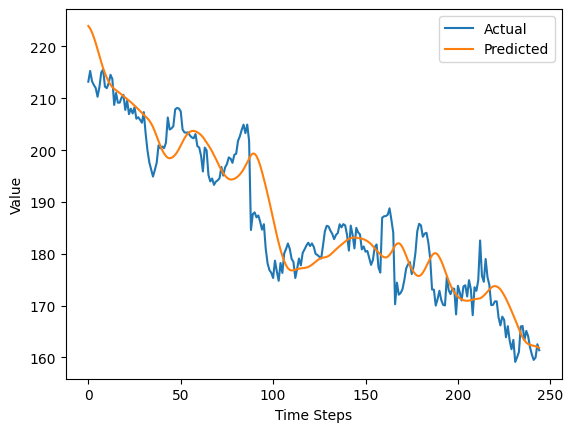

In [74]:
# Plotting (Actual vs Predicted Values)
plt.figure()
plt.plot(actual, label='Actual')
plt.plot(prediction, label='Predicted')
plt.xlabel("Time Steps")
plt.ylabel('Value')
plt.legend()
plt.show()

### **Stateful LSTM**

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

batch_size = 32

stateful_lstm = Sequential([
    Input(batch_shape=(batch_size, window_size, 1)),
    LSTM(50, stateful=True),
    Dense(1)
])

stateful_lstm.compile(optimizer='adam', loss='mse')

stateful_lstm.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (32, 50)               │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# Trim Data to match batch size
train_len = len(X_train) - (len(X_train) % batch_size)

X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

stateful_losses = []

for epoch in range(10):
  history = stateful_lstm.fit(X_train_s, y_train_s, epochs=1, batch_size=batch_size, shuffle=False, verbose=1)

  stateful_losses.append(history.history['loss'][0])

  # Reset States Safely
  for layer in stateful_lstm.layers:
    if hasattr(layer, 'reset_states'):
      layer.reset_states()

print('Stateful LSTM trained successfully')

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0124
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0119
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0090
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011    
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011    
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012    
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012
Stateful LSTM trained successfully


### **Residual LSTM**

In [77]:
inputs = Input(shape=(window_size, 1))

x = LSTM(50, return_sequences=True)(inputs)
x = LSTM(50)(x)

shortcut = LSTM(50)(inputs)

output = Add()([x, shortcut])
output = Dense(1)(output)

residual_lstm = tf.keras.Model(inputs, output)
residual_lstm.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_19 (LSTM)      │ (None, 30, 50)    │     10,400 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_20 (LSTM)      │ (None, 50)        │     20,200 │ lstm_19[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_21 (LSTM)      │ (None, 50)        │     10,400 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50)        │          0 │ lstm_20[0][0],    │
│                     │                   │            │ lstm_21[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         51 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,051 (160.36 KB)

 Trainable params: 41,051 (160.36 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history_residual = complile_and_train(residual_lstm, "Residual LSTM")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0330
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0024
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0013
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0013
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0012
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0012
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0011
Residual LSTM trained


#### Prediction

In [79]:
# Model Prediction
prediction = residual_lstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual:{actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Predicted: 225.81
Actual:213.21
Predicted: 224.10
Actual:215.28
Predicted: 222.58
Actual:213.29
Predicted: 221.05
Actual:212.56
Predicted: 219.60
Actual:211.97
Predicted: 218.27
Actual:210.29
Predicted: 216.94
Actual:212.15
Predicted: 215.94
Actual:214.99
Predicted: 215.40
Actual:215.54
Predicted: 215.17
Actual:212.24
Predicted: 214.80
Actual:211.96
Predicted: 214.44
Actual:212.89
Predicted: 214.19
Actual:214.53
Predicted: 214.16
Actual:213.74
Predicted: 214.14
Actual:208.72
Predicted: 213.67
Actual:211.04
Predicted: 213.33
Actual:209.15
Predicted: 212.83
Actual:209.16
Predicted: 212.33
Actual:210.14
Predicted: 211.95
Actual:210.67
Predicted: 211.70
Actual:207.76
Predicted: 211.25
Actual:209.56
Predicted: 210.97
Actual:206.94
Predicted: 210.49
Actual:208.00
Predicted: 210.11
Actual:207.07
Predicted: 209.70
Actual:208.29
Predicted: 209.43
Actual:206.06
Predicted: 209.02
Actual:206.35
Predicted: 208.65
Actual:205.86
Predicted: 208.27
Actual:205.28
Pr

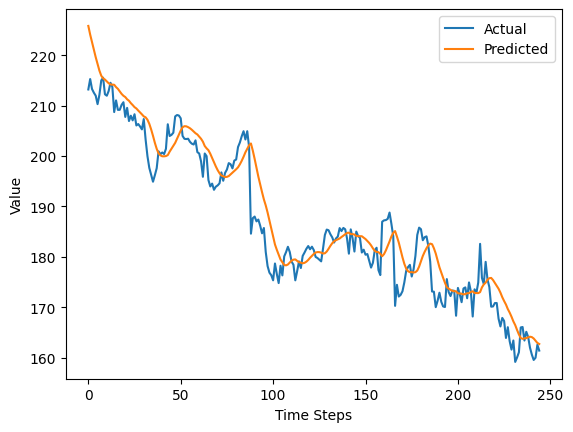

In [80]:
# Plotting (Actual vs Predicted Values)
plt.figure()
plt.plot(actual, label='Actual')
plt.plot(prediction, label='Predicted')
plt.xlabel("Time Steps")
plt.ylabel('Value')
plt.legend()
plt.show()

### Training Loss Comparison

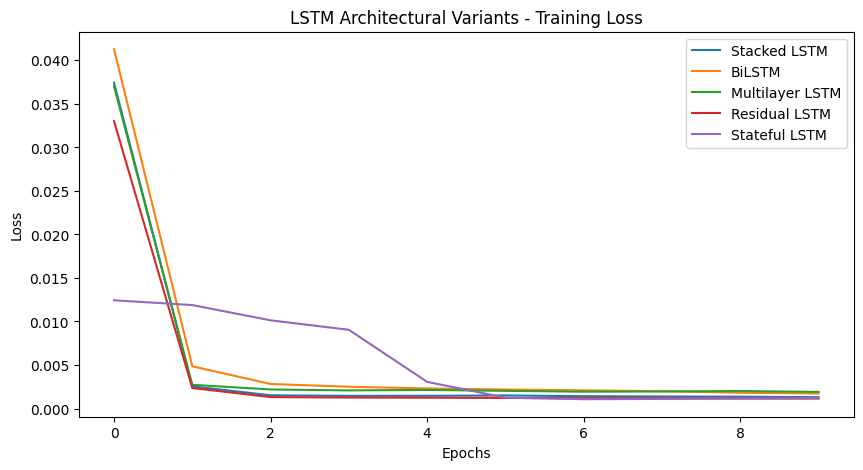

In [81]:
plt.figure(figsize=(10, 5))

plt.plot(history_stacked.history['loss'], label='Stacked LSTM')
plt.plot(history_bilstm.history['loss'], label='BiLSTM')
plt.plot(history_multilayer.history['loss'], label='Multilayer LSTM')
plt.plot(history_residual.history['loss'], label='Residual LSTM')
plt.plot(stateful_losses, label='Stateful LSTM')

plt.title('LSTM Architectural Variants - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()